# The Ocean Cleanup: Multi-Criteria Decision Analysis (MCDA)

This notebook presents a Multi-Criteria Decision Analysis (MCDA) using **Preference Function Modeling (PFM)**. It evaluates alternative solutions to The Ocean Cleanup plastic removel problem and demonstrates how stakeholders can assess design alternatives based on multiple criteria. These individual assessments are subsequently aggregated into an overall preference score for each alternative.

Many decision-making methods used in practice have a flawed mathematical foundation. These shortcomings often arise from the improper treatment of measurement scales, such as directly combining quantities expressed in different units (e.g., euros, kilograms, and square meters), aggregating ordinal data (e.g., 1st, 2nd, 3rd) with cardinal data (e.g., €1 million, €20 million, or 50 cm), or applying mathematical operations to scales for which they are not defined. For example, ranking aesthetics on a scale from 1 (best) to 4 (worst) does not imply that an alternative ranked 2 is twice as aesthetic as one ranked 4. Such practices implicitly assume measurement properties that the underlying data do not possess and can therefore lead to mathematically inconsistent results.

These issues are common in Multi-Criteria Decision Analysis (MCDA), where criteria often consist of a mixture of quantitative measures (e.g., costs or environmental impacts) and qualitative assessments (e.g., aesthetics or social acceptance). Arithmetic operations such as addition, averaging, and weighted summation are only meaningful when the underlying scales satisfy the required measurement properties. Applying these operations to ordinal scales can lead to mathematically inconsistent results, as different but equally valid numerical representations of the same preference ordering may produce different outcomes.

Preference Function Modeling addresses these challenges by first transforming each criterion onto a common preference scale prior to aggregation. This ensures that subsequent mathematical operations are meaningful, invariant to admissible transformations of the original data, and theoretically sound (Barzilai, 2010). This is achieved by eliciting preferences for each criterion and defining fixed reference points on the preference scale so that differences between alternatives become meaningful. A common approach, and the one used in this example, is to assign a value of 0 to the least preferred outcome and 100 to the most preferred outcome. The specific numerical values are not inherently important and may be changed (e.g., scales ranging from 50 to 150 are also used in the literature). What is essential is that the best and worst outcomes are explicitly defined and that intermediate alternatives are positioned proportionally between these fixed points.

Once stakeholder ratings have been correctly defined for each alternative, they must be aggregated into a single group preference score to support decision-making. PFM performs this aggregation using **affine aggregation**, which preserves the mathematical properties of the preference scales throughout the aggregation process.

This notebook demonstrates how to:

- Load and validate stakeholder ratings and criterion weights.
- Aggregate criterion ratings into a single preference score for each stakeholder (Level 1).
- Aggregate stakeholder preference scores into a single group preference score for each alternative (Level 2).

## Usage Guide

To perform an MCDA using PFM for your own System of Interest (SoI), you only need to modify the input **.csv** file containing the alternatives, criteria, stakeholder ratings, and criterion weights relevant to your case. A **.csv** (comma-separated values) file is a simple spreadsheet format that can be edited using software such as Microsoft Excel, LibreOffice Calc, or Visual Studio Code.

Provided that the structure of the input file is maintained, this notebook will automatically compute the aggregated preference scores for all stakeholders and the resulting group preference scores. Consequently, little to no modification of the notebook itself is required.

# Problem

The Great Pacific Garbage Patch (GPGP) is a patch of marine debris in the central north pacific ocean. Predicted already in 1988, the Patch has grown over time to today's size that is almost twice the sice of texas. 

Four ocean and environment protection alternatives were considered: **modular fleet**, an **anchored barrier array**, an **autonomous skimmer vessels**, and **the System 03**.

The alternatives are evaluated from the perspectives of five stakeholder groups: The Ocean Cleanup, North Pacific commercial fishers, investors/donors, marine conservation advocates, and citizens. — each rated the alternatives against their own criteria, and assigned a weight to each criterion reflecting its relative importance to them.

This notebook combines those ratings into a single group preference score per alternative, so the alternatives can be ranked and compared.


## Importing Required Packages

Below, the required packages are imported. `numpy` and `pandas` are used for data handling and numerical operations. These packages are part of the `mude-base` environment that you created in week one of MUDE.  

The local module `a_fine_aggregator` performs the actual aggregation (see `a_fine_aggregator.py` for the implementation). It is imported using a **relative import**, which depends on the directory structure of the project. When the notebook is executed within the provided directory structure, this will work as intended. However, running the notebook outside of this directory will result in the following error: `ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`


In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Round the float values in the dataframe to 2 decimal places
pd.options.display.float_format = '{:.2f}'.format

# Import local module for a-fine-aggregator
from genetic_algorithm_pfm.a_fine_aggregator import a_fine_aggregator

## Loading the Ratings Data

The stakeholder ratings are stored in `MCDA_Ratings_Ocean_Cleanup.csv`. Each row represents the evaluation of all four design alternatives by a single stakeholder for one criterion, together with the weight (`Criteria_Weight`) that the stakeholder assigns to that criterion.

For improved readability, the same information is also presented in the figure below. The figure shows that each stakeholder evaluates the alternatives based on a different set of criteria, each with its own relative importance. Note that stakeholders can have different preference functions for the same criterion. 

The list of `alternatives` is extracted from the columns between `Stakeholder`/`Criteria` and `Criteria_Weight`, while the list of `stakeholders` is obtained from the unique values in the `Stakeholder` column. Both lists are printed, and the raw ratings table is displayed to verify that the data have been imported correctly.

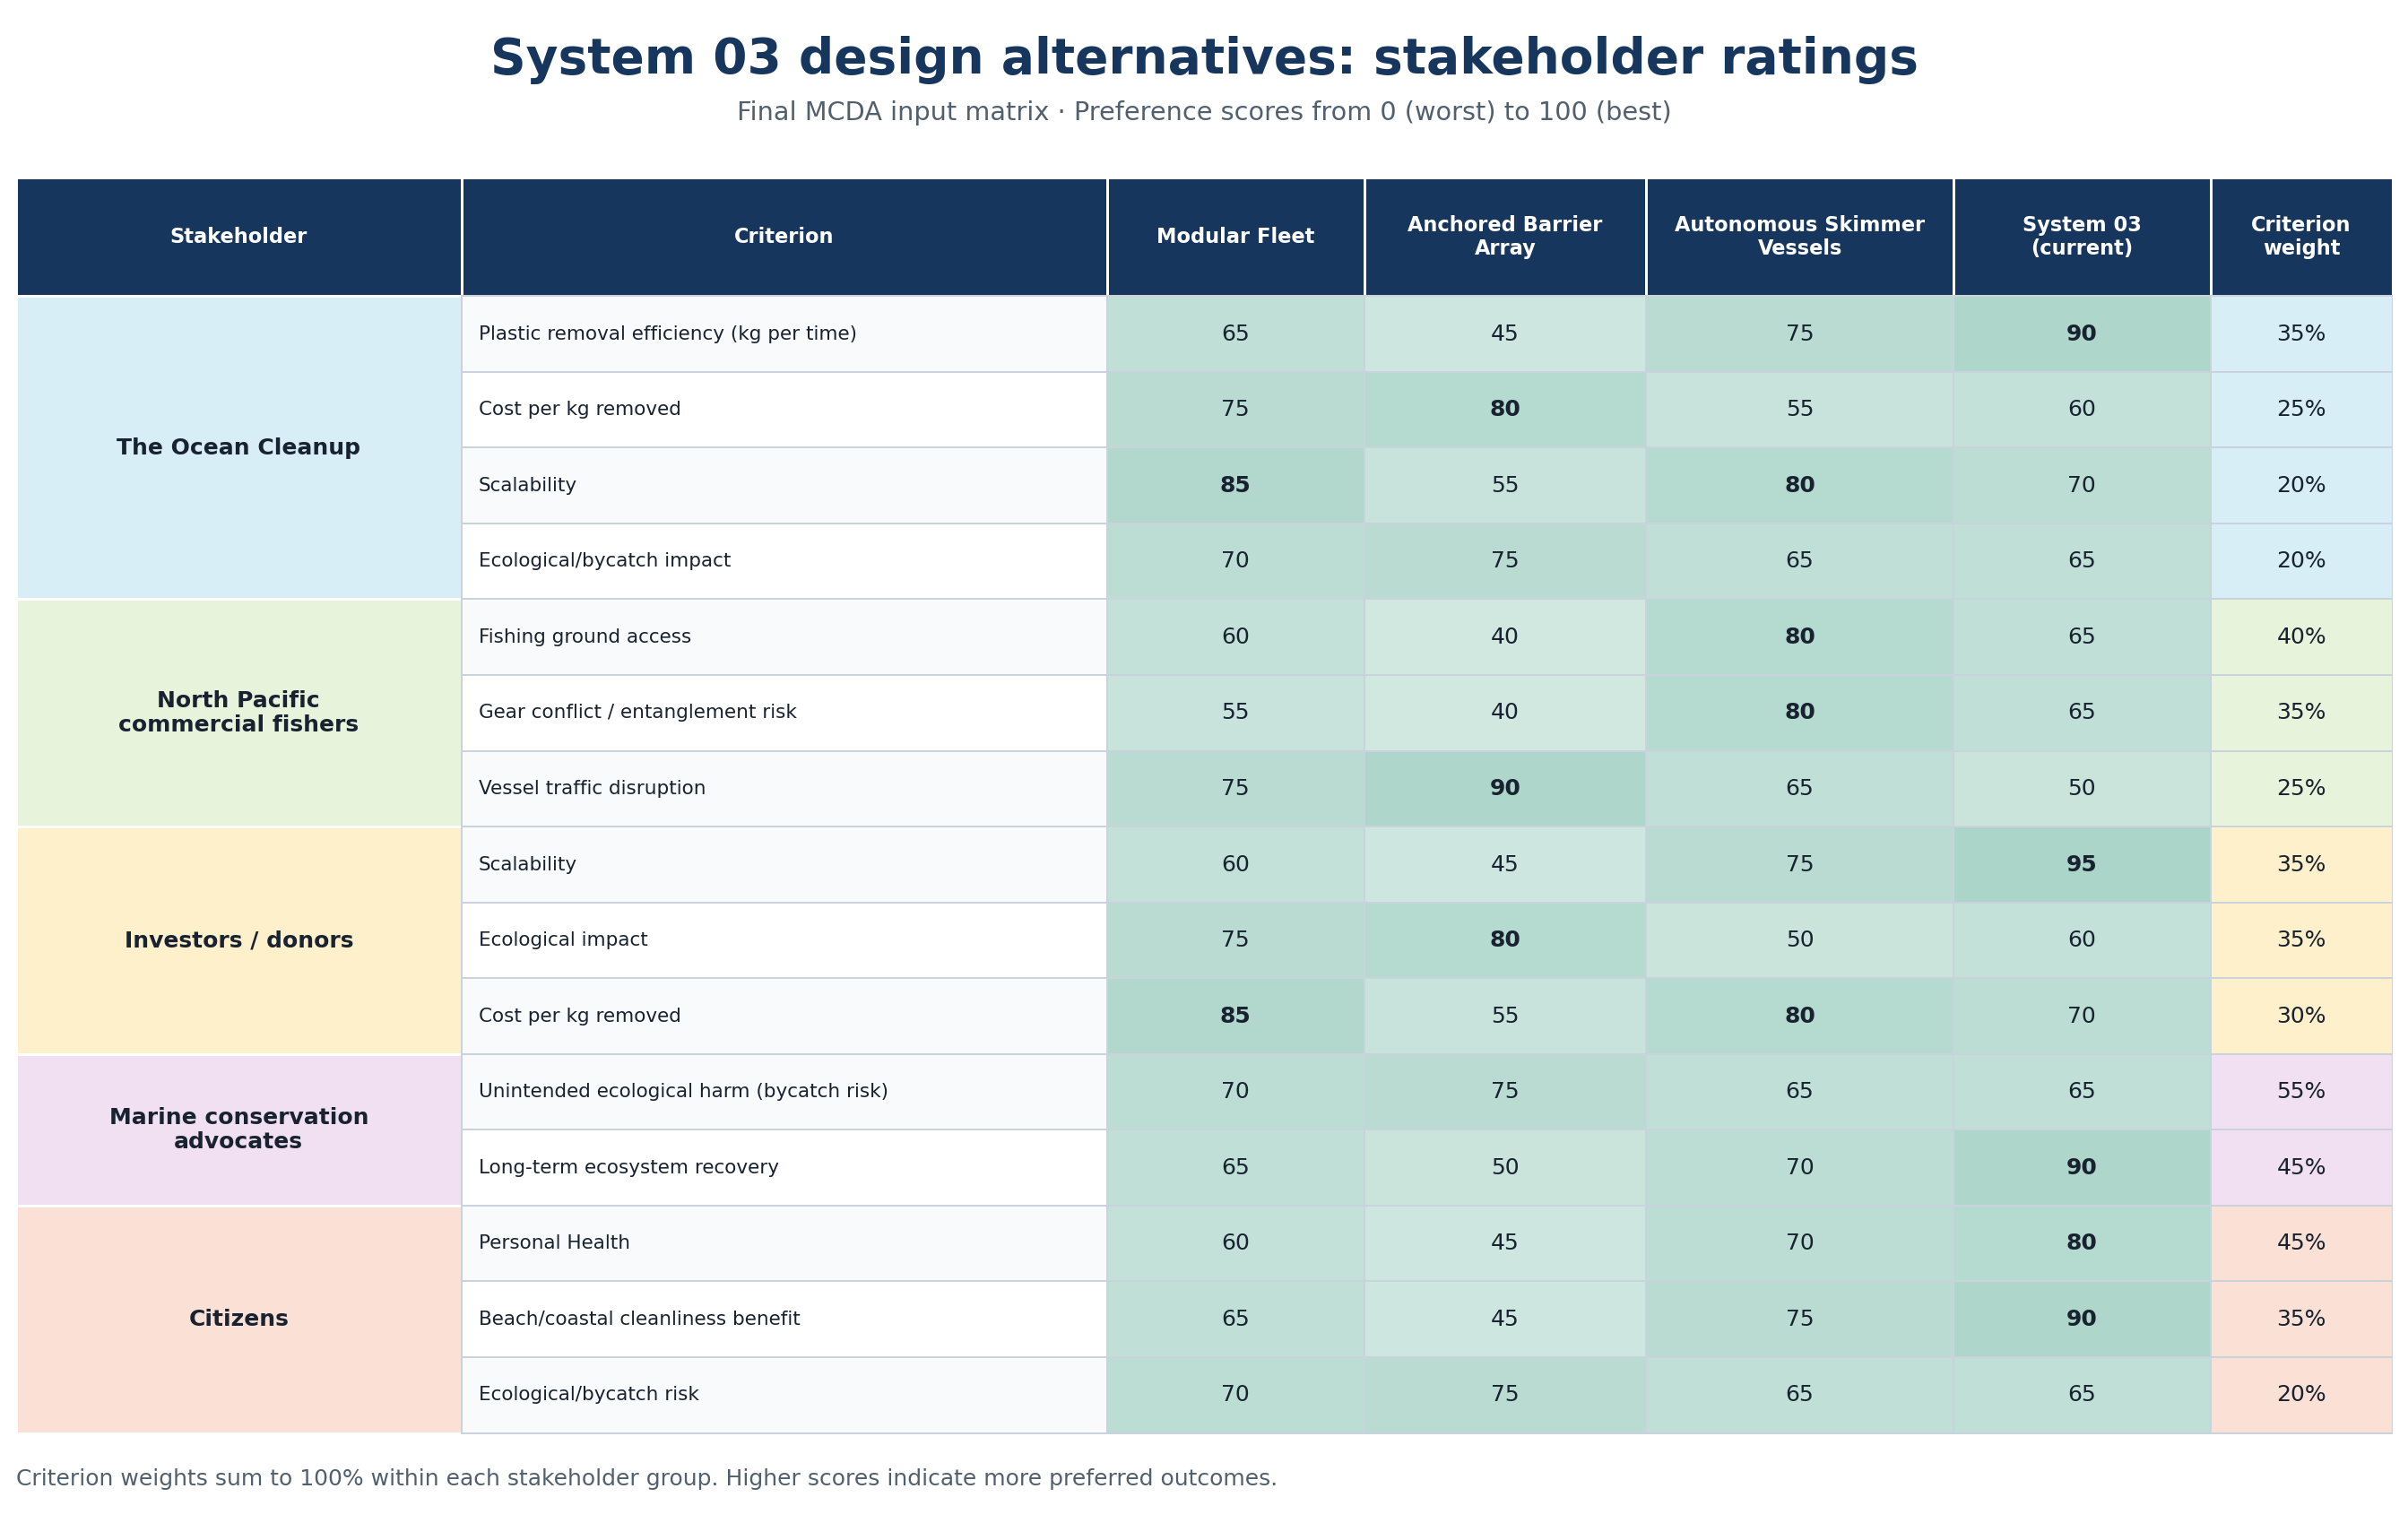

In [2]:
ratings = pd.read_csv(
    "MCDA_input/MCDA_Ratings_Ocean_Cleanup.csv",
    sep=";",       # fields are semicolon-separated, not comma-separated
    skiprows=1     # skip the  title row
)

alternatives = list(ratings.columns[2:-1].unique()) # Get the list of alternatives from the dataframe columns, excluding the first two and last column
stakeholders = list(ratings["Stakeholder"].unique()) # Get the list of stakeholders from the "Stakeholder" column in the dataframe
print(f"Alternatives: {alternatives}")
print(f"Stakeholders: {stakeholders}")
display(ratings)


Alternatives: ['Modular Fleet', 'Anchored Barrier Array', 'Autonomous Skimmer Vessels', 'System 03 (current)']
Stakeholders: ['The Ocean Cleanup', 'North Pacific commercial fishers', 'Investors/donors', 'Marine conservation advocates', 'Citizens']


,Stakeholder,Criteria,Modular Fleet,Anchored Barrier Array,Autonomous Skimmer Vessels,System 03 (current),Criteria_Weight
0,The Ocean Cleanup,Plastic removal efficiency (kg per time),65,45,75,90,0.35
1,The Ocean Cleanup,Cost per kg removed,75,80,55,60,0.25
2,The Ocean Cleanup,Scalability,85,55,80,70,0.20
3,The Ocean Cleanup,Ecological/bycatch impact,70,75,65,65,0.20
4,North Pacific commercial fishers,Fishing ground access,60,40,80,65,0.40
5,North Pacific commercial fishers,Gear conflict / entanglement risk,55,40,80,65,0.35
6,North Pacific commercial fishers,Vessel traffic disruption,75,90,65,50,0.25
7,Investors/donors,Scalability,60,45,75,95,0.35
8,Investors/donors,Ecological impact,75,80,50,60,0.35
9,Investors/donors,Cost per kg removed,85,55,80,70,0.30


## Checking the Criteria Weights

For the a-fine aggregator to produce a meaningful result, each stakeholder's criteria weights must sum to one (100%). Before aggregating anything, it is good practice to check this explicitly rather than assume the input data is correct — a silent mismatch here would otherwise propagate into the final scores without any warning.

The loop below sums the `Criteria_Weight` values per stakeholder and flags any stakeholder whose weights do not sum to 1 (within a small numerical tolerance) as a `MISMATCH`.


In [3]:
# Check each stakeholder's weights sum to 1 (i.e. 100%)
print("Check weights per stakeholder:")
all_valid = True

for stakeholder in stakeholders:
    stakeholder_weights = ratings.loc[ratings["Stakeholder"] == stakeholder, "Criteria_Weight"]
    total = stakeholder_weights.sum()
    is_valid = np.isclose(total, 1)
    all_valid &= is_valid

    status = "OK" if is_valid else "MISMATCH"
    print(f"  {stakeholder:<40s}: {total:6.2f}  [{status}]")


Check weights per stakeholder:
  The Ocean Cleanup                       :   1.00  [OK]
  North Pacific commercial fishers        :   1.00  [OK]
  Investors/donors                        :   1.00  [OK]
  Marine conservation advocates           :   1.00  [OK]
  Citizens                                :   1.00  [OK]


## Stakeholder Weights

Just as each stakeholder weighs their own criteria, the five stakeholder groups themselves must be weighted relative to one another before their individual preference scores can be combined into a single group score.

$$\sum_{i=1}^{5} w_i = 1$$

In this model, all stakeholder groups are initially weighted equally ($w_i = \tfrac{1}{5} = 0.2$), meaning no single stakeholder's preferences dominate the outcome. These weights can later be adjusted to reflect, for example, a decision-maker's judgement about whose interests should carry more weight.


In [4]:
# Set stakeholder weights
#               TOC, fishers,inv,cons,citizens
weights_eq =    [0.2, 0.2, 0.2, 0.2, 0.2]  # equal weights for stakeholders

stakeholder_weights = weights_eq 

assert np.isclose(sum(stakeholder_weights), 1), f"Weights must sum to 1, got {sum(stakeholder_weights)}"


## Aggregating the Preference Scores

The final group preference score per alternative is calculated using the `a_fine_aggregator`, in **two levels**:

1. **Level 1 — criteria → stakeholder score.** For each stakeholder, their ratings of the four alternatives on each criterion are combined using that stakeholder's own criteria weights. This produces one aggregated preference score per stakeholder per alternative.
2. **Level 2 — stakeholders → group score.** The resulting stakeholder scores (one row per stakeholder, one column per alternative) are combined a second time, now using the `stakeholder_weights` defined above, to produce a single final preference score per alternative.


The argument `scores_range=(-0.0, -100.0)` specifies that the aggregated preference scores are normalized to a range from **0** (least preferred) to **100** (most preferred). The negative range is intentional, as the affine aggregator is formulated for minimization problems and therefore operates on negative preference values.

In [5]:
# Calculate the aggregated scores for each alternative using the a-fine-aggregator
# --- Level 1: aggregate criteria ratings -> one score per stakeholder per alternative ---
stakeholder_scores = {}

for stakeholder in stakeholders:
    stakeholder_data = ratings.loc[ratings["Stakeholder"] == stakeholder]
    criteria_weights = stakeholder_data["Criteria_Weight"].to_numpy()
    p = stakeholder_data[alternatives].to_numpy()  # shape: n_criteria x n_alternatives
    stakeholder_scores[stakeholder] = a_fine_aggregator(criteria_weights, p, scores_range=(-0.0, -100.0))

# Collect into matrix: rows = stakeholders, columns = alternatives (order matches `alternatives`)
stakeholder_score_matrix = np.array([stakeholder_scores[s] for s in stakeholders])

print("Individual stakeholder aggregated scores:")
display(pd.DataFrame(stakeholder_score_matrix, index=stakeholders, columns=alternatives))

# --- Level 2: aggregate stakeholder scores -> final preference score per alternative ---
final_scores = a_fine_aggregator(stakeholder_weights, stakeholder_score_matrix, scores_range=(-0.0, -100.0))

results = (
    pd.DataFrame(final_scores, index=alternatives, columns=["Preference score"])
    .round(2)
    .sort_values("Preference score", ascending=False)
)

print("Final aggregated preference scores per alternative:")
display(results)


Individual stakeholder aggregated scores:


,Modular Fleet,Anchored Barrier Array,Autonomous Skimmer Vessels,System 03 (current)
The Ocean Cleanup,100.00,1.66,0.00,44.69
North Pacific commercial fishers,40.13,0.00,100.00,37.16
Investors/donors,100.00,0.00,37.04,81.48
Marine conservation advocates,72.54,100.00,0.00,90.18
Citizens,41.73,0.00,60.62,100.00


Final aggregated preference scores per alternative:


,Preference score
System 03 (current),100.00
Modular Fleet,97.70
Autonomous Skimmer Vessels,42.21
Anchored Barrier Array,0.00


## Interpreting the Results

The `results` table ranks the four alternatives by their final group preference score, from most to least preferred across all five stakeholder groups combined. Because the underlying scores are normalized before being combined, the results reflect each alternative's *relative* standing among the options considered — not an absolute measure of quality.

It's worth revisiting the `stakeholder_weights` (and, further upstream, each stakeholder's `Criteria_Weight` values in the CSV) to see how sensitive the final ranking is to these assumptions — a common next step in an MCDA is a simple sensitivity or scenario analysis.


## Sensitivity Analysis: Stakeholder weights 




The baseline MCDA assigns equal weights of 0.20 to all five stakeholders. This provides a neutral starting point, but it does not imply that all stakeholders have equal real-world influence.

To test the robustness of the MCDA result, two additional stakeholder-weight scenarios are considered:

1. **Influence-based weighting** — weights are adjusted according to the qualitative stakeholder influence assessment. The Ocean Cleanup receives the highest weight, followed by investors and donors. Fishers and marine conservation advocates receive equal medium influence, while citizens receive the lowest weight.

2. **Environmental priority** — marine conservation advocates receive increased influence to represent a situation in which environmental requirements become more important.

Only stakeholder weights are changed. The criterion weights and alternative preference scores remain unchanged in all scenarios. All stakeholder-weight sets sum to 1.00.

In [6]:
print(stakeholders)

['The Ocean Cleanup', 'North Pacific commercial fishers', 'Investors/donors', 'Marine conservation advocates', 'Citizens']


In [7]:
# ---------------------------------------------------------
# Sensitivity analysis: stakeholder-weight scenarios
# ---------------------------------------------------------

sensitivity_scenarios = {

    "Baseline - Equal weights": {
        "The Ocean Cleanup": 0.20,
        "North Pacific commercial fishers": 0.20,
        "Investors/donors": 0.20,
        "Marine conservation advocates": 0.20,
        "Citizens": 0.20
    },

    "Influence-based weighting": {
        "The Ocean Cleanup": 0.30,
        "North Pacific commercial fishers": 0.175,
        "Investors/donors": 0.225,
        "Marine conservation advocates": 0.175,
        "Citizens": 0.125
    },

    "Environmental priority": {
        "The Ocean Cleanup": 0.20,
        "North Pacific commercial fishers": 0.15,
        "Investors/donors": 0.15,
        "Marine conservation advocates": 0.35,
        "Citizens": 0.15
    }
}

# Check that scenario stakeholder names match the notebook stakeholder names
for scenario_name, scenario_weights in sensitivity_scenarios.items():

    missing = set(stakeholders) - set(scenario_weights.keys())
    extra = set(scenario_weights.keys()) - set(stakeholders)

    if missing or extra:
        print(f"{scenario_name}:")
        print("  Missing stakeholders:", missing)
        print("  Extra stakeholders:", extra)

In [8]:
# Check that the weights in every scenario sum to 1.00

print("Stakeholder-weight validation:")

for scenario_name, scenario_weights in sensitivity_scenarios.items():

    total = sum(scenario_weights.values())
    valid = np.isclose(total, 1.0)

    status = "OK" if valid else "MISMATCH"

    print(f"{scenario_name:<30s}: {total:.3f} [{status}]")

    assert valid, f"{scenario_name} weights sum to {total}, not 1.0"

Stakeholder-weight validation:
Baseline - Equal weights      : 1.000 [OK]
Influence-based weighting     : 1.000 [OK]
Environmental priority        : 1.000 [OK]


In [9]:
# ---------------------------------------------------------
# Recalculate final preference scores for each scenario
# ---------------------------------------------------------

scenario_scores = {}
scenario_rankings = {}

for scenario_name, scenario_weights_dict in sensitivity_scenarios.items():

    # Put weights into the same order as the stakeholder_score_matrix
    scenario_weights = np.array([
        scenario_weights_dict[stakeholder]
        for stakeholder in stakeholders
    ])

    # Level 2 aggregation:
    # stakeholder scores -> overall group preference score
    scores = a_fine_aggregator(
        scenario_weights,
        stakeholder_score_matrix,
        scores_range=(-0.0, -100.0)
    )

    scenario_scores[scenario_name] = scores

    # Rank 1 = highest preference
    ranks = pd.Series(
        scores,
        index=alternatives
    ).rank(
        ascending=False,
        method="min"
    ).astype(int)

    scenario_rankings[scenario_name] = ranks

In [10]:
# ---------------------------------------------------------
# Compare preference scores across scenarios
# ---------------------------------------------------------

sensitivity_results = pd.DataFrame(
    scenario_scores,
    index=alternatives
).round(2)

print("Preference scores under each stakeholder-weight scenario:")
display(sensitivity_results)

Preference scores under each stakeholder-weight scenario:


,Baseline - Equal weights,Influence-based weighting,Environmental priority
Modular Fleet,97.70,100.00,95.87
Anchored Barrier Array,0.00,0.00,7.98
Autonomous Skimmer Vessels,42.21,29.88,0.00
System 03 (current),100.00,83.72,100.00


In [11]:
# ---------------------------------------------------------
# Change in preference score relative to baseline
# Positive means the alternative gains preference; 
# negative means it loses preference.
# ---------------------------------------------------------

baseline_scores = sensitivity_results["Baseline - Equal weights"]

score_changes = pd.DataFrame(index=alternatives)

for scenario_name in sensitivity_results.columns:

    if scenario_name != "Baseline - Equal weights":
        score_changes[scenario_name] = (
            sensitivity_results[scenario_name] - baseline_scores
        )

score_changes = score_changes.round(2)

print("Change in preference score relative to baseline:")
display(score_changes)

Change in preference score relative to baseline:


,Influence-based weighting,Environmental priority
Modular Fleet,2.30,-1.83
Anchored Barrier Array,0.00,7.98
Autonomous Skimmer Vessels,-12.33,-42.21
System 03 (current),-16.28,0.00


### Results Interpretation

The results show that the ranking is not completely robust to stakeholder weighting. Under the equal-weight baseline, System 03 ranks first, narrowly ahead of Modular Fleet. Under the influence-based scenario, Modular Fleet becomes the preferred alternative, while System 03 drops substantially in preference. This occurs because the scenario gives greater influence to The Ocean Cleanup and investors/donors, both of whom give Modular Fleet relatively strong stakeholder-level scores. Under the environmental-priority scenario, System 03 remains the preferred alternative, while Autonomous Skimmer Vessels loses considerable preference and the Anchored Barrier Array improves slightly. This reflects the increased influence of marine conservation advocates, who strongly prefer System 03 and the Anchored Barrier Array relative to Autonomous Skimmer Vessels. Overall, the analysis indicates that the preferred alternative depends especially on how much influence is assigned to operational/economic stakeholders compared with environmental stakeholders, so the final MCDA outcome is sensitive to stakeholder-weight assumptions rather than fully robust.

Under equal stakeholder weights, System 03 ranks first, narrowly ahead of Modular Fleet. This result is mainly driven by System 03’s strong preference scores from citizens, marine conservation advocates and investors/donors, particularly for long-term ecosystem recovery, scalability and perceived health/cleanliness benefits. Modular Fleet performs especially strongly for The Ocean Cleanup and investors/donors, which explains why it becomes the preferred option when stakeholder weights are adjusted according to influence. The main stakeholder disagreement is therefore between operational/economic priorities, which favour Modular Fleet more strongly, and environmental/social priorities, which support System 03. The sensitivity analysis shows that the result is not fully robust: System 03 remains preferred under equal and environmental-priority weighting, but Modular Fleet becomes preferred under influence-based weighting. This means the final ranking depends materially on assumptions about stakeholder influence. The analysis is also limited by the qualitative nature of the preference scores and weights, which reflect judgement rather than measured technical performance. The aggregated scores should therefore be interpreted as relative preferences among the four alternatives, not as absolute measures of engineering quality.


#### Comparison with Realised System03


The baseline MCDA identifies System 03 as the preferred alternative, which corresponds with the realised design. Its high ranking is produced mainly by strong scores from citizens and marine conservation advocates, together with a high investor/donor preference, especially for long-term ecosystem recovery, scalability and visible cleanup benefits. However, the sensitivity analysis shows that this agreement with reality is not inevitable: under influence-based stakeholder weights, Modular Fleet becomes preferred. This suggests that the realised choice of System 03 cannot be interpreted as the uniquely optimal solution, but rather as one outcome that performs strongly under the selected stakeholder assumptions. In practice, implementation may also depend on feasibility, available funding, stakeholder influence, operational constraints and other practical considerations beyond the simplified MCDA. Regardless of the MCDA outcome, System 03 remains the appropriate variant for the later MODO because the assignment requires optimisation of the realised system.